# 🏀 Clutch Performance Analysis Framework
### Heist 2026 Datathon @ UCI

#### Team Name: DataEaters

#### Team: Tyler Camelot, Sruthi Raj Perikala, Manaal Fatima, Claudia Garcia


**Primary Question:** How do coaches determine which players to trust in the final moments of a game?


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# Data Sources

| Dataset | Role |
|---------|------|
| `play_by_play.csv` | NBA Play-by-Play — event-level game actions (clutch proxy) |
| `AllStar_Selections.csv` | Player recognition proxy |
| `Player_Award_Shares.csv` | Historical performance proxy |


In [3]:
pbp     = pd.read_csv('play_by_play.csv')
awards  = pd.read_csv('Player Award Shares.csv')
allstar = pd.read_csv('All-Star Selections.csv')

print(f"Play-by-Play : {pbp.shape[0]:,} rows | {pbp['game_id'].nunique()} unique games (SAMPLE of full dataset)")
print(f"Awards       : {awards.shape[0]:,} rows | seasons {awards['season'].min()}–{awards['season'].max()}")
print(f"All-Star     : {allstar.shape[0]:,} rows | seasons {allstar['season'].min()}–{allstar['season'].max()}")
print()
print("PBP columns:", list(pbp.columns))


Play-by-Play : 13,592,899 rows | 29818 unique games (SAMPLE of full dataset)
Awards       : 3,465 rows | seasons 1948–2025
All-Star     : 2,058 rows | seasons 1951–2026

PBP columns: ['game_id', 'eventnum', 'eventmsgtype', 'eventmsgactiontype', 'period', 'wctimestring', 'pctimestring', 'homedescription', 'neutraldescription', 'visitordescription', 'score', 'scoremargin', 'person1type', 'player1_id', 'player1_name', 'player1_team_id', 'player1_team_city', 'player1_team_nickname', 'player1_team_abbreviation', 'person2type', 'player2_id', 'player2_name', 'player2_team_id', 'player2_team_city', 'player2_team_nickname', 'player2_team_abbreviation', 'person3type', 'player3_id', 'player3_name', 'player3_team_id', 'player3_team_city', 'player3_team_nickname', 'player3_team_abbreviation', 'video_available_flag']


# Data Dictionaries

### NBA Event Message Types (eventmsgtype)
| Code | Event |
|------|-------|
| 1 | Made field goal |
| 2 | Missed field goal *(player3 = blocker if present)* |
| 3 | Free throw |
| 5 | Turnover *(player2 = stealer if present)* |
| 6 | Foul |
| 8 | Substitution |


In [4]:
print("=== Awards sample ===")
display(awards.head(4))
print("\n=== All-Star sample ===")
display(allstar.head(4))


=== Awards sample ===


,season,award,player,player_id,age,first,pts_won,pts_max,share,winner
0,2025,nba clutch_poy,Jalen Brunson,brunsja01,28,70.0,426.0,500.0,0.852,True
1,2025,nba clutch_poy,Nikola Jokić,jokicni01,29,26.0,312.0,500.0,0.624,False
2,2025,nba clutch_poy,Anthony Edwards,edwaran01,23,2.0,47.0,500.0,0.094,False
3,2025,nba clutch_poy,Trae Young,youngtr01,26,0.0,44.0,500.0,0.088,False



=== All-Star sample ===


,player,player_id,team,season,lg,replaced
0,Scottie Barnes,barnesc01,Team Stars,2026,NBA,False
1,Devin Booker,bookede01,Team Stars,2026,NBA,False
2,Cade Cunningham,cunnica01,Team Stars,2026,NBA,False
3,Jalen Duren,durenja01,Team Stars,2026,NBA,False


# Feature Engineering Pipeline

### Step 1 — Define Clutch Situations

**Clutch** = Q4 or overtime, last 5 minutes of play, score margin ≤ 5 points (absolute value).


In [5]:
# ── Parse shot-clock seconds remaining ──────────────────────────────────
def parse_seconds(t):
    try:
        m, s = str(t).split(':')
        return int(m) * 60 + int(s)
    except Exception:
        return np.nan

pbp['seconds_remaining'] = pbp['pctimestring'].apply(parse_seconds)

# ── Parse absolute score margin from raw 'scoremargin' column ─────────
def parse_abs_margin(m):
    if pd.isna(m) or str(m).strip() == 'TIE':
        return 0
    try:
        return abs(int(m))
    except Exception:
        return np.nan

pbp['abs_margin'] = pbp['scoremargin'].apply(parse_abs_margin)

# ── Clutch flag ─────────────────────────────────────────────────────────
pbp['is_clutch'] = (
    (pbp['period'] >= 4) &
    (pbp['seconds_remaining'] <= 300) &
    (pbp['abs_margin'] <= 5)
)

pbp_clutch = pbp[pbp['is_clutch']].copy()
pbp_q1q3   = pbp[pbp['period'] <= 3].copy()

print(f"Total events   : {len(pbp):,}")
print(f"Clutch events  : {len(pbp_clutch):,}  ({100*len(pbp_clutch)/len(pbp):.1f}%)")
print(f"Q1–Q3 events   : {len(pbp_q1q3):,}")
print()
print("Clutch event type breakdown:")
type_map = {1:'Made FG', 2:'Missed FG', 3:'Free Throw', 5:'Turnover', 6:'Foul'}
print(pbp_clutch['eventmsgtype'].map(type_map).value_counts().dropna())


Total events   : 13,592,899
Clutch events  : 1,459,931  (10.7%)
Q1–Q3 events   : 9,957,821

Clutch event type breakdown:
eventmsgtype
Missed FG     308176
Foul          180472
Free Throw    136673
Turnover       93280
Made FG        85223
Name: count, dtype: int64


### Step 2 — Extract Clutch-Time Statistics per Player

In [6]:
# Made field goals
made_fg = (pbp_clutch[pbp_clutch['eventmsgtype'] == 1]
           .groupby('player1_name').size().rename('clutch_made_fg'))

# Attempted field goals (made + missed)
att_fg = (pbp_clutch[pbp_clutch['eventmsgtype'].isin([1, 2])]
          .groupby('player1_name').size().rename('clutch_att_fg'))

# Free throws made (exclude rows where description contains MISS)
ft_df = pbp_clutch[pbp_clutch['eventmsgtype'] == 3].copy()
ft_df['ft_made'] = ~(
    ft_df['homedescription'].str.contains('MISS', na=False) |
    ft_df['visitordescription'].str.contains('MISS', na=False)
)
ft_made = ft_df[ft_df['ft_made']].groupby('player1_name').size().rename('clutch_ft_made')
ft_att  = ft_df.groupby('player1_name').size().rename('clutch_ft_att')

# Blocks: player3 credited on type-2 (missed FG) events
blocks = (pbp_clutch[(pbp_clutch['eventmsgtype'] == 2) & pbp_clutch['player3_name'].notna()]
          .groupby('player3_name').size().rename('clutch_blocks'))

# Steals: player2 credited on type-5 (turnover) events
steals = (pbp_clutch[(pbp_clutch['eventmsgtype'] == 5) & pbp_clutch['player2_name'].notna()]
          .groupby('player2_name').size().rename('clutch_steals'))

# Turnovers committed (player1 on type-5)
turnovers = (pbp_clutch[pbp_clutch['eventmsgtype'] == 5]
             .groupby('player1_name').size().rename('clutch_turnovers'))

# ── Assemble player-level clutch table ───────────────────────────────────
clutch_stats = (pd.concat([made_fg, att_fg, ft_made, ft_att], axis=1)
                .join(blocks, how='outer')
                .join(steals, how='outer')
                .join(turnovers, how='outer')
                .fillna(0).astype(int)
                .reset_index()
                .rename(columns={'player1_name': 'player'}))

clutch_stats['clutch_fg_pct'] = (
    clutch_stats['clutch_made_fg'] / clutch_stats['clutch_att_fg'].replace(0, np.nan)
).fillna(0)

print(f"Players with clutch activity: {len(clutch_stats)}")
display(clutch_stats.sort_values('clutch_made_fg', ascending=False).head(15))


Players with clutch activity: 2765


,index,clutch_made_fg,clutch_att_fg,clutch_ft_made,clutch_ft_att,clutch_blocks,clutch_steals,clutch_turnovers,clutch_fg_pct
1653,LeBron James,779,2721,732,1262,155,236,531,0.286292
1584,Kobe Bryant,636,2650,721,1039,69,194,415,0.240000
2273,Russell Westbrook,572,2068,476,760,44,176,446,0.276596
740,Dirk Nowitzki,517,1873,645,791,122,94,258,0.276028
1546,Kevin Durant,488,1722,489,649,155,95,301,0.283391
2508,Tim Duncan,485,1448,429,836,273,87,331,0.334945
2168,Ray Allen,480,1676,426,552,35,136,279,0.286396
2091,Paul Pierce,476,1696,654,966,93,150,339,0.280660
796,Dwyane Wade,473,1685,438,722,140,178,336,0.280712
360,Carmelo Anthony,465,1766,438,634,60,115,271,0.263307


# Clutch Metric Construction

### A8.1 — Composite Performance Metric (CPM)

$$CPM = w_1(\text{Scoring}) + w_2(\text{Efficiency}) + w_3(\text{Blocks}) + w_4(\text{Steals}) + w_5(\text{FT}) - w_6(\text{Turnovers})$$

**Weights (descending importance):** Made shots > Efficiency > Blocks > Steals > Free throws > Turnovers (penalty)


In [8]:
cs

,index,clutch_made_fg,clutch_att_fg,clutch_ft_made,clutch_ft_att,clutch_blocks,clutch_steals,clutch_turnovers,clutch_fg_pct,norm_made_fg,norm_fg_pct,norm_blocks,norm_steals,norm_ft,norm_turnovers,CPM
0,A.C. Green,14,72,18,42,5,18,13,0.194444,0.017972,0.194444,0.018315,0.071713,0.024590,0.024482,0.064549
1,A.J. Bramlett,0,2,0,0,0,1,0,0.000000,0.000000,0.000000,0.000000,0.003984,0.000000,0.000000,0.000478
2,A.J. Guyton,1,51,1,6,1,1,9,0.019608,0.001284,0.019608,0.003663,0.003984,0.001366,0.016949,0.003946
3,A.J. Lawson,1,7,2,5,0,3,3,0.142857,0.001284,0.142857,0.000000,0.011952,0.002732,0.005650,0.036969
4,AJ Green,0,20,0,0,0,2,4,0.000000,0.000000,0.000000,0.000000,0.007968,0.000000,0.007533,-0.000174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2760,Ziv Maoz,0,2,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2761,Zoran Dragic,1,13,0,1,0,0,2,0.076923,0.001284,0.076923,0.000000,0.000000,0.000000,0.003766,0.019115
2762,Zoran Planinic,0,41,0,15,0,12,22,0.000000,0.000000,0.000000,0.000000,0.047809,0.000000,0.041431,-0.000478
2763,Zydrunas Ilgauskas,137,465,145,223,99,34,97,0.294624,0.175866,0.294624,0.362637,0.135458,0.198087,0.182674,0.194306


In [9]:
W_SCORING    = 0.35
W_EFFICIENCY = 0.25
W_BLOCKS     = 0.15
W_STEALS     = 0.12
W_FT         = 0.08
W_TO         = 0.15   # penalty

def normalize_col(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else pd.Series(0.0, index=s.index)

cs = clutch_stats.copy()
cs['norm_made_fg']   = normalize_col(cs['clutch_made_fg'])
cs['norm_fg_pct']    = normalize_col(cs['clutch_fg_pct'])
cs['norm_blocks']    = normalize_col(cs['clutch_blocks'])
cs['norm_steals']    = normalize_col(cs['clutch_steals'])
cs['norm_ft']        = normalize_col(cs['clutch_ft_made'])
cs['norm_turnovers'] = normalize_col(cs['clutch_turnovers'])

cs['CPM'] = (
    W_SCORING    * cs['norm_made_fg'] +
    W_EFFICIENCY * cs['norm_fg_pct'] +
    W_BLOCKS     * cs['norm_blocks'] +
    W_STEALS     * cs['norm_steals'] +
    W_FT         * cs['norm_ft'] -
    W_TO         * cs['norm_turnovers']
)

cs = cs.rename(columns={'index': 'player'})

print("Top 15 by CPM:")
display(cs[['player','clutch_made_fg','clutch_fg_pct','clutch_blocks',
            'clutch_steals','clutch_turnovers','CPM']]
        .sort_values('CPM', ascending=False).head(15))


Top 15 by CPM:


,player,clutch_made_fg,clutch_fg_pct,clutch_blocks,clutch_steals,clutch_turnovers,CPM
1653,LeBron James,779,0.286292,155,236,531,0.549566
2508,Tim Duncan,485,0.334945,273,87,331,0.446620
1584,Kobe Bryant,636,0.240000,69,194,415,0.437978
1549,Kevin Garnett,430,0.287433,205,176,311,0.418791
740,Dirk Nowitzki,517,0.276028,122,94,258,0.410876
796,Dwyane Wade,473,0.280712,140,178,336,0.397670
1546,Kevin Durant,488,0.283391,155,95,301,0.389101
2091,Paul Pierce,476,0.280660,93,150,339,0.382554
2657,Vince Carter,458,0.271166,101,134,260,0.369735
2273,Russell Westbrook,572,0.276596,44,176,446,0.360497


# Clutch Performance Index (CPI)

Min-max normalization scales CPM to [0, 1]:

$$CPI = \frac{CPM - \min(CPM)}{\max(CPM) - \min(CPM)}$$


In [13]:
cs['CPI'] = normalize_col(cs['CPM'])

clutch_final = cs[['player','clutch_made_fg','clutch_att_fg','clutch_fg_pct',
                    'clutch_ft_made','clutch_blocks','clutch_steals',
                    'clutch_turnovers','CPM','CPI']].copy()

print("CPI distribution:")
print(clutch_final['CPI'].describe().round(4))
print()
print("Top 20 Clutch Players by CPI:")
display(clutch_final.sort_values('CPI', ascending=False).head(20))


CPI distribution:
count    2765.0000
mean        0.1098
std         0.1177
min         0.0000
25%         0.0159
50%         0.0721
75%         0.1585
max         1.0000
Name: CPI, dtype: float64

Top 20 Clutch Players by CPI:


,player,clutch_made_fg,clutch_att_fg,clutch_fg_pct,clutch_ft_made,clutch_blocks,clutch_steals,clutch_turnovers,CPM,CPI
1653,LeBron James,779,2721,0.286292,732,155,236,531,0.549566,1.000000
2508,Tim Duncan,485,1448,0.334945,429,273,87,331,0.446620,0.815334
1584,Kobe Bryant,636,2650,0.240000,721,69,194,415,0.437978,0.799833
1549,Kevin Garnett,430,1496,0.287433,410,205,176,311,0.418791,0.765415
740,Dirk Nowitzki,517,1873,0.276028,645,122,94,258,0.410876,0.751216
796,Dwyane Wade,473,1685,0.280712,438,140,178,336,0.397670,0.727528
1546,Kevin Durant,488,1722,0.283391,489,155,95,301,0.389101,0.712156
2091,Paul Pierce,476,1696,0.280660,654,93,150,339,0.382554,0.700412
2657,Vince Carter,458,1689,0.271166,458,101,134,260,0.369735,0.677418
2273,Russell Westbrook,572,2068,0.276596,476,44,176,446,0.360497,0.660848


# Non-Clutch Feature Dataset (Q1–Q3 Only)

Using **only Q1–Q3 data** prevents data leakage — the model never sees clutch-time information as a predictor.


In [14]:
q13_made = (pbp_q1q3[pbp_q1q3['eventmsgtype'] == 1]
            .groupby('player1_name').size().rename('q13_made_fg'))
q13_att  = (pbp_q1q3[pbp_q1q3['eventmsgtype'].isin([1, 2])]
            .groupby('player1_name').size().rename('q13_att_fg'))
q13_blk  = (pbp_q1q3[(pbp_q1q3['eventmsgtype'] == 2) & pbp_q1q3['player3_name'].notna()]
            .groupby('player3_name').size().rename('q13_blocks'))
q13_stl  = (pbp_q1q3[(pbp_q1q3['eventmsgtype'] == 5) & pbp_q1q3['player2_name'].notna()]
            .groupby('player2_name').size().rename('q13_steals'))
q13_to   = (pbp_q1q3[pbp_q1q3['eventmsgtype'] == 5]
            .groupby('player1_name').size().rename('q13_turnovers'))

q13_stats = (pd.concat([q13_made, q13_att], axis=1)
             .join(q13_blk, how='outer')
             .join(q13_stl, how='outer')
             .join(q13_to, how='outer')
             .fillna(0).astype(int)
             .reset_index()
             .rename(columns={'player1_name': 'player'}))

q13_stats['q13_fg_pct'] = (
    q13_stats['q13_made_fg'] / q13_stats['q13_att_fg'].replace(0, np.nan)
).fillna(0)

print(f"Q1–Q3 player profiles: {len(q13_stats)}")
display(q13_stats.sort_values('q13_made_fg', ascending=False).head(10))


Q1–Q3 player profiles: 2668


,index,q13_made_fg,q13_att_fg,q13_blocks,q13_steals,q13_turnovers,q13_fg_pct
1589,LeBron James,11222,21935,846,1743,4061,0.511602
1525,Kobe Bryant,8693,19039,484,1517,2934,0.456589
2415,Tim Duncan,8401,16476,2368,816,2745,0.509893
712,Dirk Nowitzki,8304,17359,958,916,1829,0.478369
355,Carmelo Anthony,7732,17139,487,943,2302,0.451135
1489,Kevin Durant,7726,15351,857,890,2617,0.503290
1492,Kevin Garnett,7646,15201,1407,1352,2222,0.502993
2287,Shaquille O'Neal,6675,11471,1514,383,2020,0.581902
2195,Russell Westbrook,6552,14898,246,1369,3428,0.439791
2554,Vince Carter,6475,14780,582,1073,1762,0.438092


# Data Integration

All datasets merged into a **single player-level analytical dataset** using player names as join keys.  
Name standardization: lowercase, strip whitespace, remove suffixes (Jr., III, etc.).


In [21]:
# Awards Types
def clean_name(n):
    if pd.isna(n):
        return ''
    n = str(n).lower().strip()
    n = re.sub(r'\b(jr\.?|sr\.?|ii|iii|iv)\b', '', n)
    return ' '.join(n.split())

# All-Star aggregates
allstar['player_clean'] = allstar['player'].apply(clean_name)
allstar_agg = (allstar.groupby('player_clean')
               .agg(allstar_count=('season', 'count'))
               .reset_index())

# Award aggregates — individual column per award type (winners only)
awards['player_clean'] = awards['player'].apply(clean_name)

AWARD_MAP = {
    'nba mvp':  'mvp_count',
    'nba mip':  'mip_count',
    'nba dpoy': 'dpoy_count',
    'nba smoy': 'smoy_count',
    'nba roy':  'roy_count',
}

nba_awards = awards[awards['award'].isin(AWARD_MAP.keys()) & (awards['winner'] == True)]

award_agg = (nba_awards
             .groupby(['player_clean', 'award'])['winner']
             .sum()
             .unstack(fill_value=0)
             .rename(columns=AWARD_MAP)
             .reset_index())

# Ensure all award columns exist even if no player ever won that award
for col in AWARD_MAP.values():
    if col not in award_agg.columns:
        award_agg[col] = 0

# Clean join keys
clutch_final['player_clean'] = clutch_final['player'].apply(clean_name)
q13_stats = q13_stats.rename(columns={'index': 'player'}) if 'index' in q13_stats.columns else q13_stats
q13_stats['player_clean'] = q13_stats['player'].apply(clean_name)

# Merge
analytical = (clutch_final
              .merge(q13_stats.drop(columns='player'), on='player_clean', how='left')
              .merge(allstar_agg, on='player_clean', how='left')
              .merge(award_agg,   on='player_clean', how='left'))

# Fill missing award/allstar counts with 0
award_cols = list(AWARD_MAP.values())
analytical['allstar_count'] = analytical['allstar_count'].fillna(0).astype(int)
for col in award_cols:
    analytical[col] = analytical[col].fillna(0).astype(int)

print(f"Final analytical dataset: {analytical.shape[0]} players × {analytical.shape[1]} features")
display(analytical[['player', 'CPI', 'allstar_count'] + award_cols]
        .sort_values('CPI', ascending=False).head(20))


Final analytical dataset: 2771 players × 23 features


,player,CPI,allstar_count,mvp_count,mip_count,dpoy_count,smoy_count,roy_count
1657,LeBron James,1.000000,22,4,0,0,0,1
2514,Tim Duncan,0.815334,15,2,0,0,0,1
1588,Kobe Bryant,0.799833,18,1,0,0,0,0
1553,Kevin Garnett,0.765415,15,1,0,1,0,0
740,Dirk Nowitzki,0.751216,14,1,0,0,0,0
796,Dwyane Wade,0.727528,13,0,0,0,0,0
1550,Kevin Durant,0.712156,16,1,0,0,0,1
2097,Paul Pierce,0.700412,10,0,0,0,0,0
2663,Vince Carter,0.677418,8,0,0,0,0,1
2279,Russell Westbrook,0.660848,9,1,0,0,0,0


# Exploratory Data Analysis

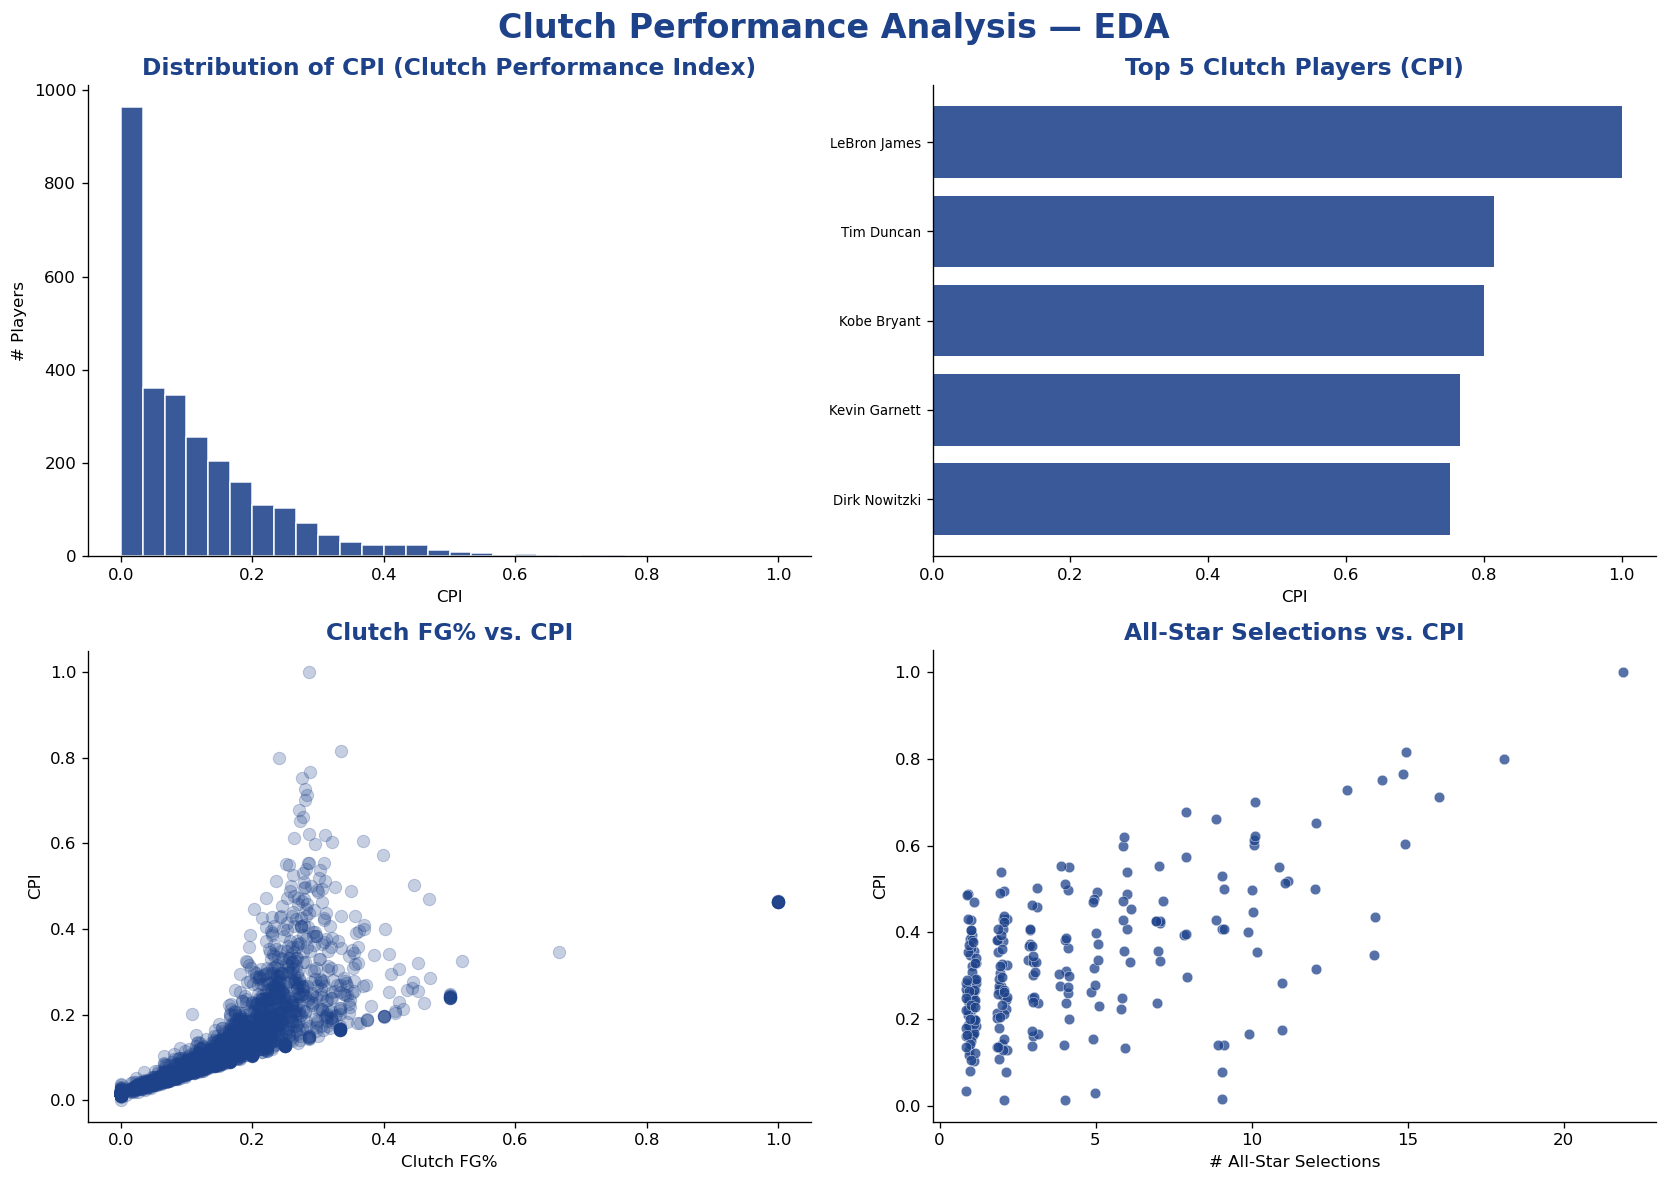

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Clutch Performance Analysis — EDA', fontsize=20, fontweight='bold',
             color='#1D428A')

# NBA official palette
NBA_BLUE    = '#1D428A'
NBA_RED     = '#C8102E'
NBA_SILVER  = '#C4CED4'
NBA_GOLD    = '#FFC72C'
NBA_WHITE   = '#FFFFFF'

# 1) CPI distribution
ax = axes[0, 0]
ax.hist(analytical['CPI'], bins=30, color=NBA_BLUE, alpha=0.88, edgecolor=NBA_WHITE)
ax.set_title('Distribution of CPI (Clutch Performance Index)',
             color=NBA_BLUE, fontsize=14, fontweight='bold')
ax.set_xlabel('CPI'); ax.set_ylabel('# Players')

# 2) Top 5 by CPI
ax = axes[0, 1]
top5 = analytical.sort_values('CPI', ascending=False).head(5)
ax.barh(top5['player'], top5['CPI'], color=NBA_BLUE, alpha=0.88)
ax.invert_yaxis()
ax.set_title('Top 5 Clutch Players (CPI)',
             color=NBA_BLUE, fontsize=14, fontweight='bold')
ax.set_xlabel('CPI')
ax.tick_params(axis='y', labelsize=8)

# 3) Clutch FG% vs CPI

ax = axes[1, 0]
ax.scatter(analytical['clutch_fg_pct'], analytical['CPI'],
           color=NBA_BLUE, alpha=0.25, edgecolors=NBA_BLUE,
           linewidths=0.6, s=55)
ax.set_title('Clutch FG% vs. CPI',
             color=NBA_BLUE, fontsize=14, fontweight='bold')
ax.set_xlabel('Clutch FG%'); ax.set_ylabel('CPI')



# 4) All-Star count vs CPI (jittered) — All-Stars only, blue tiers
ax = axes[1, 1]
allstar_only = analytical[analytical['allstar_count'] > 0].copy()

# Blue gradient tiers for All-Star selections
colors = {
    1: '#93B5E1',   # light blue — 1 selection
    2: '#4A7EC7',   # mid blue  — 2 selections
    3: NBA_BLUE,    # deep NBA blue — 3+ selections
}
for n_as in sorted(allstar_only['allstar_count'].unique()):
    grp = allstar_only[allstar_only['allstar_count'] == n_as]
    jitter = np.random.uniform(-0.18, 0.18, len(grp))
    label = f'{int(n_as)} All-Star sel.'
    ax.scatter(grp['allstar_count'] + jitter, grp['CPI'],
               alpha=0.75, label=label, color=NBA_BLUE, s=40,
               edgecolors='white', linewidths=0.3)

ax.set_title('All-Star Selections vs. CPI',
             color=NBA_BLUE, fontsize=14, fontweight='bold')
ax.set_xlabel('# All-Star Selections'); ax.set_ylabel('CPI')

plt.tight_layout()
plt.show()

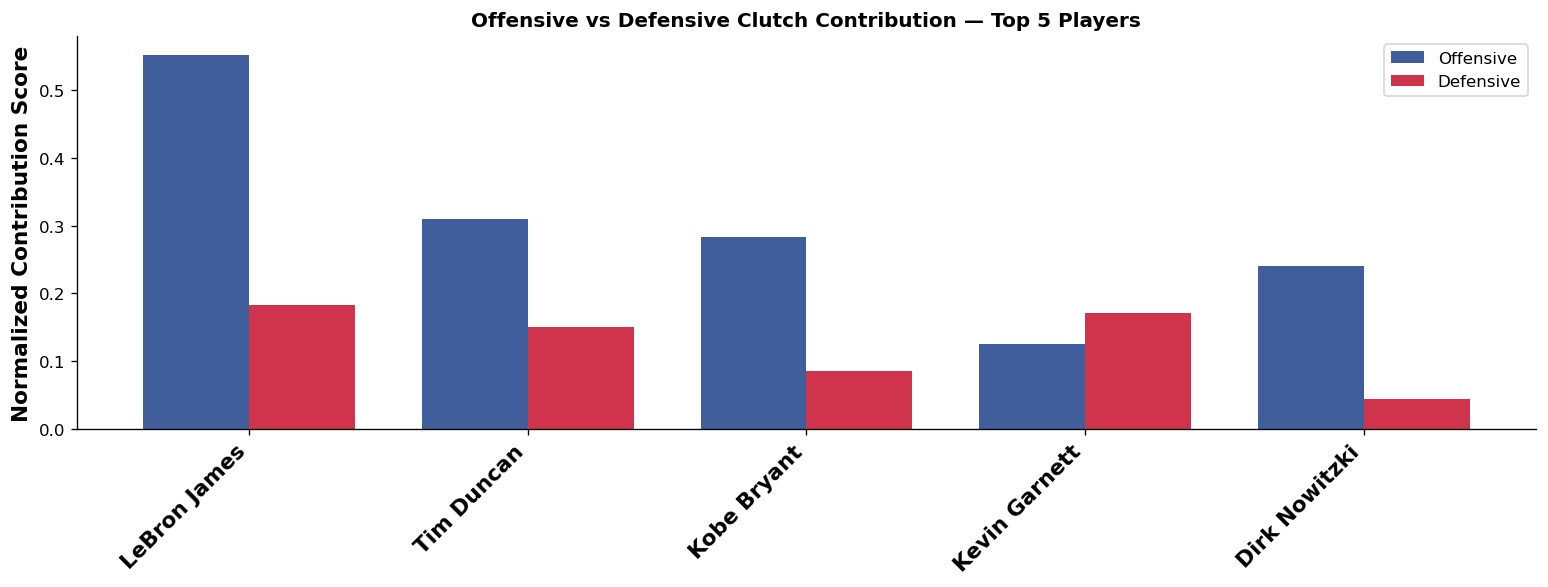

In [47]:
# Offensive vs Defensive contribution — top 20 players
top20 = analytical.sort_values('CPI', ascending=False).head(5).copy()

top20['off_score'] = (
    0.35 * normalize_col(top20['clutch_made_fg']) +
    0.25 * normalize_col(top20['clutch_fg_pct']) +
    0.08 * normalize_col(top20['clutch_ft_made']) 
)
top20['def_score'] = (
    0.15 * normalize_col(top20['clutch_blocks']) +
    0.12 * normalize_col(top20['clutch_steals'])
)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(top20))
w = 0.38
ax.bar(x - w/2, top20['off_score'], width=w, label='Offensive', color=NBA_BLUE, alpha=0.85)
ax.bar(x + w/2, top20['def_score'], width=w, label='Defensive',  color=NBA_RED, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top20['player'], rotation=45, ha='right', fontsize=13, fontweight='bold')
ax.set_title('Offensive vs Defensive Clutch Contribution — Top 5 Players', fontweight='bold')
ax.set_ylabel('Normalized Contribution Score',fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


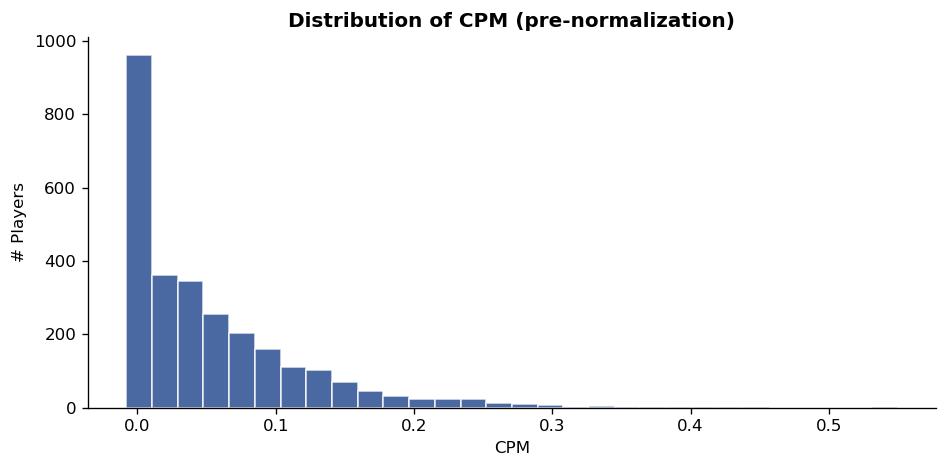

CPM stats:
count    2771.0000
mean        0.0534
std         0.0657
min        -0.0079
25%         0.0010
50%         0.0324
75%         0.0806
max         0.5496
Name: CPM, dtype: float64


In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(analytical['CPM'], bins=30, color=NBA_BLUE, alpha=0.8, edgecolor='white')
ax.set_title('Distribution of CPM (pre-normalization)', fontweight='bold')
ax.set_xlabel('CPM'); ax.set_ylabel('# Players')
plt.tight_layout()
plt.show()

print(f"CPM stats:\n{analytical['CPM'].describe().round(4)}")


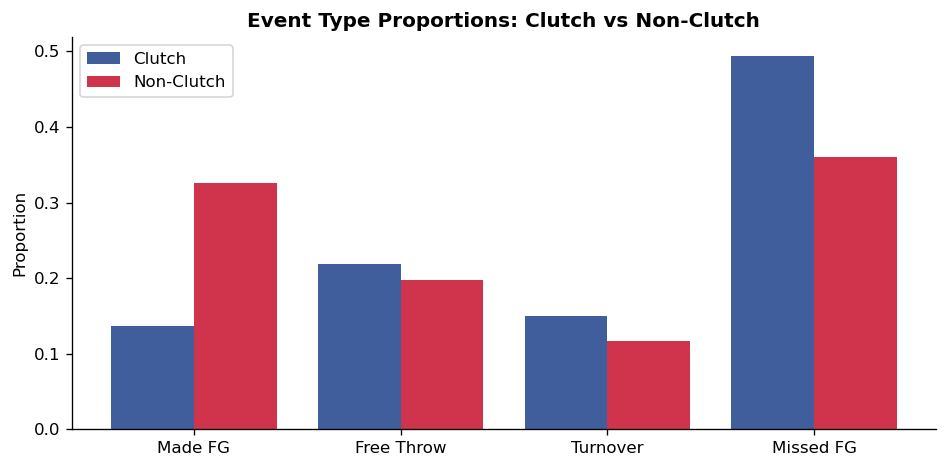

In [50]:
# Event proportion: clutch vs non-clutch
event_types = {1:'Made FG', 2:'Missed FG', 3:'Free Throw', 5:'Turnover'}
clutch_counts   = pbp[pbp['is_clutch']]['eventmsgtype'].map(event_types).value_counts()
nonclutch_counts = pbp[~pbp['is_clutch']]['eventmsgtype'].map(event_types).value_counts()

labels = list(set(clutch_counts.index) | set(nonclutch_counts.index))
cc = [clutch_counts.get(l, 0) / clutch_counts.sum() for l in labels]
nc = [nonclutch_counts.get(l, 0) / nonclutch_counts.sum() for l in labels]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, cc, 0.4, label='Clutch', color=NBA_BLUE, alpha=0.85)
ax.bar(x + 0.2, nc, 0.4, label='Non-Clutch', color=NBA_RED, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Event Type Proportions: Clutch vs Non-Clutch', fontweight='bold')
ax.set_ylabel('Proportion'); ax.legend()
plt.tight_layout()
plt.show()


# Modeling Framework

**Target:** CPI (continuous regression) or binary "elite clutch" flag (CPI ≥ 0.7)

**Features (Q1–Q3 + career indicators - no leakage):**
- `q13_made_fg`, `q13_fg_pct`, `q13_blocks`, `q13_steals`, `q13_turnovers`
- `allstar_count`, `award_wins`, `mvp_shares`

**Steps:**

1. Define features and target variable (CPI)
2. Split data into training and test sets
3. Train candidate models (Ridge, Random Forest, Gradient Boosting)
4. Perform 5-fold cross-validation on training data
5. Select best model based on average CV R²
6. Fit final model on full training set
7. Evaluate on test set (R², RMSE, MAE)
8. Interpret results using Ridge coefficients
9. Conduct residual analysis


In [58]:
FEATURES = [
    'q13_made_fg', 'q13_fg_pct', 'q13_blocks', 'q13_steals', 'q13_turnovers',
    'allstar_count',
    *award_cols
]

model_df = analytical[FEATURES + ['CPI']].dropna()
X = model_df[FEATURES]
y = model_df['CPI']

print(f"Modeling dataset: {len(model_df)} players, {len(FEATURES)} features\n")

Modeling dataset: 2579 players, 11 features



In [60]:
# Train / test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {len(X_train)} players")
print(f"Test set:     {len(X_test)} players\n")

Training set: 2063 players
Test set:     516 players



In [61]:
# Define candidate models
models = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    
    'Random Forest': Pipeline([
        ('model', RandomForestRegressor(n_estimators=200, random_state=42))
    ]),
    
    'Gradient Boosting': Pipeline([
        ('model', GradientBoostingRegressor(n_estimators=200, random_state=42))
    ]),
}

In [63]:
# Cross-validation on TRAIN only
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

print("Cross-validated training performance:")
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')
    results[name] = scores.mean()
    print(f"  {name:25s} R² = {scores.mean():.3f} ± {scores.std():.3f}")

best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"\nBest model from CV: {best_name} (CV R² = {results[best_name]:.3f})")

Cross-validated training performance:
  Ridge Regression          R² = 0.827 ± 0.041
  Random Forest             R² = 0.805 ± 0.038
  Gradient Boosting         R² = 0.826 ± 0.038

Best model from CV: Ridge Regression (CV R² = 0.827)



Final model performance:
  Train R²:   0.831
  Test R²:    0.792
  Train RMSE: 0.049
  Test RMSE:  0.054
  Train MAE:  0.033
  Test MAE:   0.035


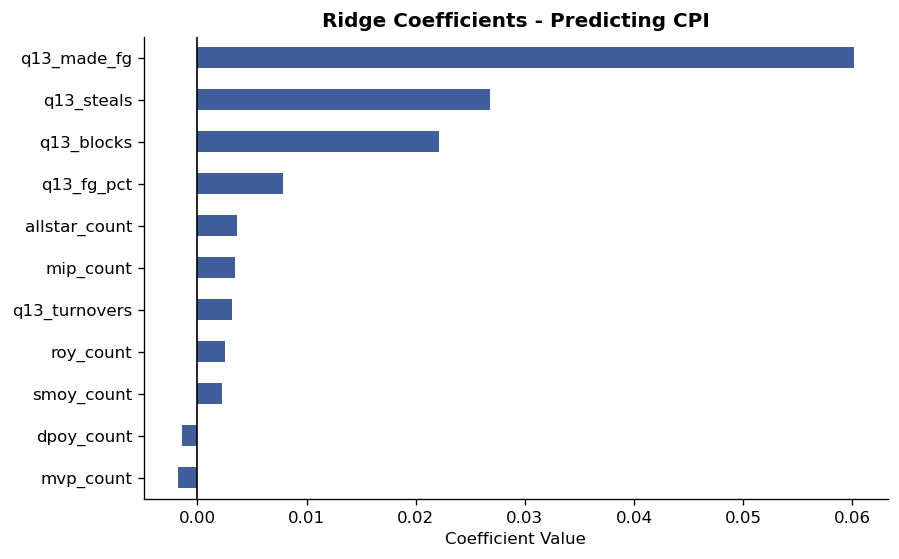

In [76]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

# Fit best model on full training set
best_model.fit(X_train, y_train)

# Evaluate on test set
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\nFinal model performance:")
print(f"  Train R²:   {train_r2:.3f}")
print(f"  Test R²:    {test_r2:.3f}")
print(f"  Train RMSE: {train_rmse:.3f}")
print(f"  Test RMSE:  {test_rmse:.3f}")
print(f"  Train MAE:  {train_mae:.3f}")
print(f"  Test MAE:   {test_mae:.3f}")

# -----------------------------------
# Ridge coefficient interpretation
# -----------------------------------
ridge_model = best_model.named_steps['model']

coef_series = pd.Series(
    ridge_model.coef_,
    index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
coef_series.plot(kind='barh', ax=ax, color=NBA_BLUE, alpha=0.85)


ax.axvline(0, color='black', linewidth=1)
ax.set_title('Ridge Coefficients - Predicting CPI', fontweight='bold')
ax.set_xlabel('Coefficient Value')


plt.show()

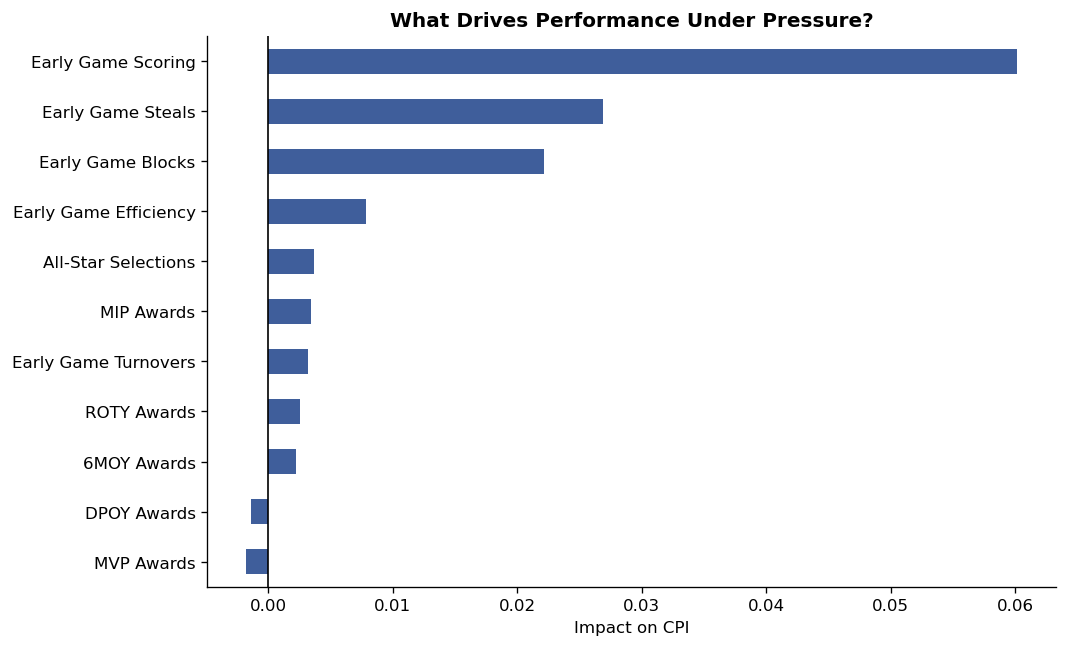

In [83]:
ridge_model = best_model.named_steps['model']

coef_plot = pd.Series(ridge_model.coef_, index=FEATURES).sort_values()

# Label mapping
label_map = {
    'q13_made_fg': 'Early Game Scoring',
    'q13_fg_pct': 'Early Game Efficiency',
    'q13_blocks': 'Early Game Blocks',
    'q13_steals': 'Early Game Steals',
    'q13_turnovers': 'Early Game Turnovers',
    'allstar_count': 'All-Star Selections',
    'mvp_count': 'MVP Awards',
    'dpoy_count': 'DPOY Awards',
    'smoy_count': '6MOY Awards',
    'roy_count': 'ROTY Awards',
    'mip_count': 'MIP Awards'
}

# Apply readable labels
coef_plot.index = [label_map.get(idx, idx) for idx in coef_plot.index]

# Plot
fig, ax = plt.subplots(figsize=(9, 5.5))
coef_plot.plot(kind='barh', ax=ax, color=NBA_BLUE, alpha=0.85)

ax.axvline(0, color='black', linewidth=1)
ax.set_title('What Drives Performance Under Pressure?', fontweight='bold')
ax.set_xlabel('Impact on CPI')

plt.tight_layout()
plt.show()

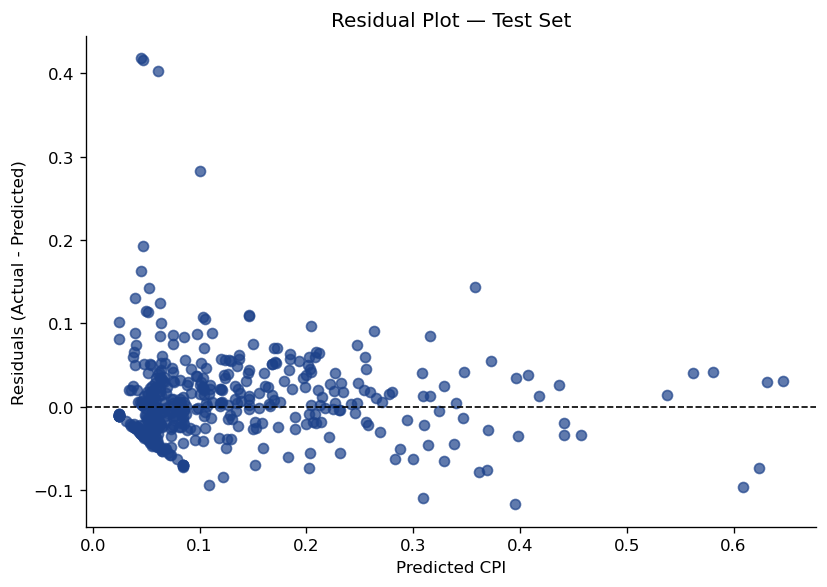

In [75]:
# Residual plot on TEST set
residuals = y_test - y_test_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_test_pred, residuals, alpha=0.7, color=NBA_BLUE)

plt.axhline(0, linestyle='--', color='black', linewidth=1)

plt.xlabel("Predicted CPI")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot — Test Set")

plt.tight_layout()
plt.show()

**Focus on 3–5 key takeaways:**

1. Identify the strongest drivers
   q13_made_fg → strongest positive driver of CPI
   Players who score more leading into clutch tend to perform better in clutch
2. Secondary contributors
   q13_steals, q13_blocks → meaningful positive impact
   Defensive activity contributes to clutch performance
3. Efficiency vs volume
   q13_fg_pct is positive but smaller than made FG
   Volume scoring > efficiency in predicting clutch impact
4. Turnovers
   Slight positive (or small effect)
   Likely noise or contextual (can mention cautiously)
5. Awards / accolades
   Mostly small or negligible impact
   Past accolades are less predictive than current game performance